<a href="https://colab.research.google.com/github/aadzy/ML-lab-2547201/blob/Lab-6/BreastCancer_data_with_LogReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import cross_val_score

from sklearn.model_selection import GridSearchCV

##Task 1: Data Preparation


In [ ]:
from sklearn.datasets import load_breast_cancer
# Loaded the dataset
bc = load_breast_cancer()

# Create a DataFrame
df = pd.DataFrame(bc.data, columns=bc.feature_names)

display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
display(df.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

In [ ]:
df.info()

print("Dataset shape:",df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df.isnull().sum()


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


### Data Quality Assessment

The dataset was checked for missing values and duplicate records. No missing values or duplicates were found, indicating that the dataset is clean and ready for preprocessing.

In [ ]:

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

# Convert the scaled data back to a DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

df_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


## Training KNN model with Heuristic K

In [ ]:
heuristic_k = 21

k_values = [heuristic_k + i for i in [-4, -2, 0, 2, 4]]

print("K values tested:", k_values)

accuracies = []

for current_k in k_values:
    knn = KNeighborsClassifier(n_neighbors=current_k)
    knn.fit(X_train_80, y_train_80)

    y_pred = knn.predict(X_test_80)

    acc = accuracy_score(y_test_80, y_pred)
    accuracies.append(acc)

    print(f"K = {current_k:2d} | Accuracy = {acc:.4f}")

K values tested: [17, 19, 21, 23, 25]
K = 17 | Accuracy = 0.9737
K = 19 | Accuracy = 0.9737
K = 21 | Accuracy = 0.9561
K = 23 | Accuracy = 0.9649
K = 25 | Accuracy = 0.9649


In [ ]:
best_index = np.argmax(accuracies)

best_k = k_values[best_index]
best_accuracy = accuracies[best_index]

print(f"Best K: {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")

Best K: 17
Best Accuracy: 0.9737


## Using Cross-validation to optimize the KNN model for better accuracy

In [ ]:
from sklearn.model_selection import cross_val_score

k_values = list(range(best_k - 5, best_k + 6, 2))
cv_mean_accuracy = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_80,
        y_train_80,
        cv=5,
        scoring='accuracy'
    )

    cv_mean_accuracy.append(scores.mean())

    print(f"K = {k:2d} | Mean CV Accuracy = {scores.mean():.4f}")


K = 12 | Mean CV Accuracy = 0.9670
K = 14 | Mean CV Accuracy = 0.9648
K = 16 | Mean CV Accuracy = 0.9604
K = 18 | Mean CV Accuracy = 0.9582
K = 20 | Mean CV Accuracy = 0.9582
K = 22 | Mean CV Accuracy = 0.9560


In [ ]:
best_cv_index = np.argmax(cv_mean_accuracy)

best_k = k_values[best_cv_index]
best_cv_accuracy = cv_mean_accuracy[best_cv_index]

print(f"Best K from Cross Validation: {best_k}")
print(f"Mean CV Accuracy: {best_cv_accuracy:.4f}")

Best K from Cross Validation: 12
Mean CV Accuracy: 0.9670


In [ ]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_80, y_train_80)

# Predictions
y_pred = final_knn.predict(X_test_80)

# Probabilities for ROC Curve
y_prob = final_knn.predict_proba(X_test_80)[:, 1]

## Metrics for KNN Model

In [ ]:
accuracy = accuracy_score(y_test_80, y_pred)
precision = precision_score(y_test_80, y_pred)
recall = recall_score(y_test_80, y_pred)
f1 = f1_score(y_test_80, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9737
Precision: 0.9600
Recall   : 1.0000
F1 Score : 0.9796


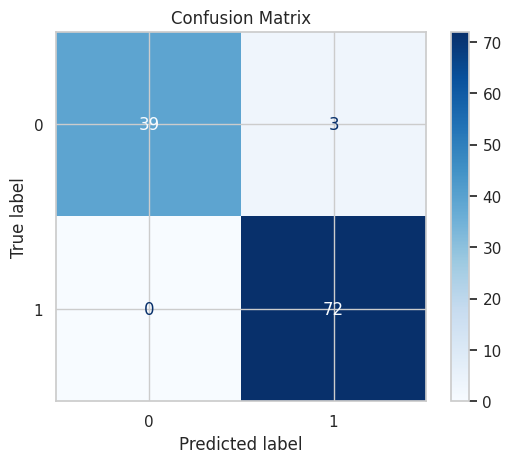

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_80, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

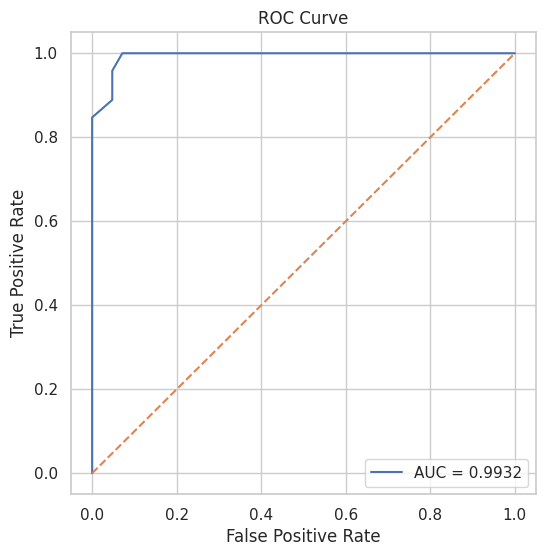

AUC: 0.9932


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_80, y_prob)
auc = roc_auc_score(y_test_80, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print(f"AUC: {auc:.4f}")

## Training a Logistic Regression Model


In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_80, y_train_80)

# Predictions
y_pred_lr = log_reg.predict(X_test_80)
y_prob_lr = log_reg.predict_proba(X_test_80)[:, 1]

# Evaluation Metrics for LR
accuracy_lr = accuracy_score(y_test_80, y_pred_lr)
precision_lr = precision_score(y_test_80, y_pred_lr)
recall_lr = recall_score(y_test_80, y_pred_lr)
f1_lr = f1_score(y_test_80, y_pred_lr)

print(f"Logistic Regression Accuracy : {accuracy_lr:.4f}")
print(f"Logistic Regression Precision: {precision_lr:.4f}")
print(f"Logistic Regression Recall   : {recall_lr:.4f}")
print(f"Logistic Regression F1 Score : {f1_lr:.4f}")

Logistic Regression Accuracy : 0.9825
Logistic Regression Precision: 0.9861
Logistic Regression Recall   : 0.9861
Logistic Regression F1 Score : 0.9861


## Final Model Comparison: KNN vs. Logistic Regression

We will now visualize the performance of both models side-by-side and summarize the findings.

In [ ]:

final_comparison = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'KNN (K=12)': [accuracy, precision, recall, f1, auc],
    'Logistic Regression': [accuracy_lr, precision_lr, recall_lr, f1_lr, auc_lr]
}

final_df = pd.DataFrame(final_comparison).set_index('Metric')
display(final_df.style.highlight_max(axis=1, color='green'))

,KNN (K=12),Logistic Regression
Metric,,
Accuracy,0.973684,0.982456
Precision,0.960000,0.986111
Recall,1.000000,0.986111
F1 Score,0.979592,0.986111
ROC AUC,0.993221,0.995370


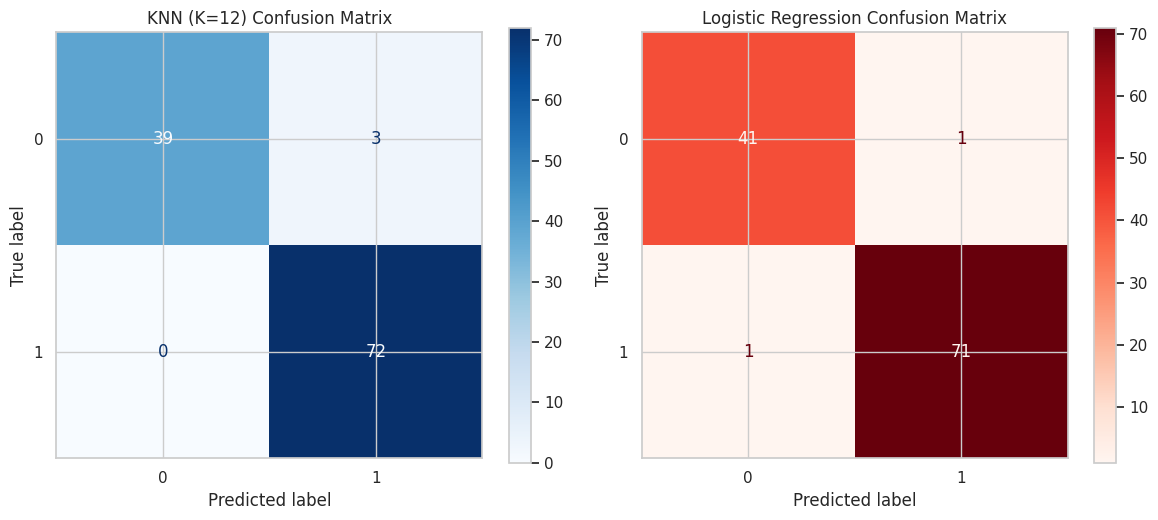

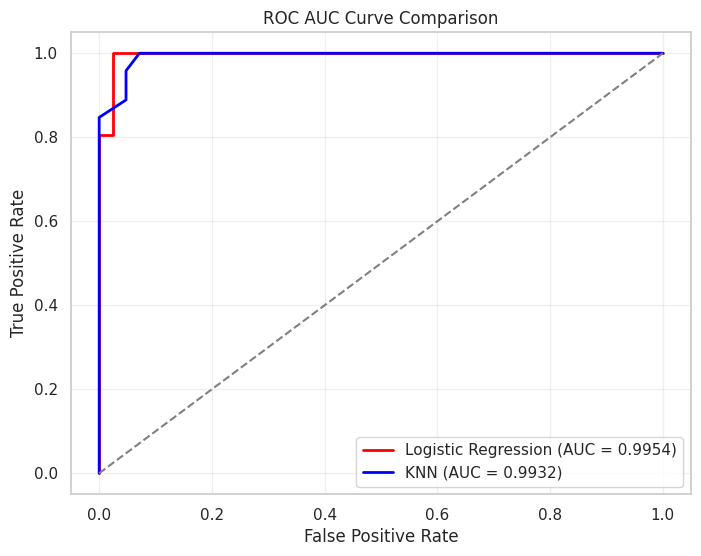

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

auc_lr = roc_auc_score(y_test_80, y_prob_lr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm_knn = confusion_matrix(y_test_80, y_pred)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot(ax=ax1, cmap='Blues')
ax1.set_title(f"KNN (K={best_k}) Confusion Matrix")

cm_lr = confusion_matrix(y_test_80, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot(ax=ax2, cmap='Reds')
ax2.set_title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test_80, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test_80, y_prob)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='red', lw=2)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc:.4f})', color='blue', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### Final Interpretation

- **Logistic Regression** outperformed KNN in **Accuracy** (98.25% vs 97.37%), **Precision**, and **F1 Score**.
- **KNN** achieved a perfect **Recall** (100%), meaning it correctly identified every single malignant case in the test set. Logistic Regression missed one malignant case (False Negative).
- However, Logistic Regression had fewer False Positives (1 vs 3 for KNN).
- **Conclusion:** For medical diagnosis, Recall is often prioritized (not missing any cancer cases). While Logistic Regression is more accurate overall, the perfect recall of the tuned KNN model is a significant advantage. If a balance is preferred to avoid unnecessary biopsies (Precision), Logistic Regression is the superior choice for this specific dataset.